# Notebook 5 — Brain K-Space Fingerprint Atlas

---

## The Core Argument

> **The physics of spatial frequency encoding does the work — not an algorithm guessing from grayscale values.**

Every radiologist and every AI diagnostic model works on reconstructed images — grayscale pictures derived from raw scanner data. But reconstruction is lossy. Phase information is discarded. Frequency-domain structure collapses into pixel values. By the time a pixel exists, some of what the scanner measured is already gone.

---

## Why K-Space Is Fundamentally More Precise

This is the key insight — and it comes from the mathematics of the Fourier transform.

**In image space:** a pixel at position (x, y) tells you the local intensity at that one point. A tumor that occupies 1% of the image affects only that 1% of pixels. An AI model looking at image space sees a local patch.

**In k-space:** every single point encodes a *global* property of the entire image. A point at frequency (kx, ky) represents the contribution of that spatial frequency across the whole field of view. This means:

```
Image space:   tumor occupies ~1% of pixels   →  AI sees a local patch
K-space:       tumor changes 100% of k-space  →  signal is everywhere, always
```

A tumor — no matter how small — changes the frequency distribution of the entire k-space. Its cellular density (high spatial frequency), its bulk size (low spatial frequency), and its boundary sharpness (mid-to-high frequency phase) all leave measurable signatures across the full k-space grid.

---

## What This Means for Tumor Margins

Tumor margin delineation is one of the hardest problems in radiation oncology. Standard practice adds **1-2cm margins** around the visible tumor boundary because the image-space boundary is uncertain — partial volume effects, reconstruction blurring, and pixel noise all make the edge imprecise.

In k-space, boundaries are encoded differently:
- The sharpness of a boundary = amplitude of high-frequency k-space components
- The location of a boundary = phase of those components
- The difference between tumor tissue and surrounding normal tissue = a specific frequency band signature

This encoding is in the raw signal — before reconstruction blurs it. The hypothesis: **tumor margins are more precisely defined in k-space than in the reconstructed image.**

This notebook builds evidence for that claim.

---

## The Dataset: 5 Sequence Types, 186 Patients

| Sequence | What It Captures |
|---|---|
| **FLAIR** | Suppresses CSF — lesions and white matter abnormalities appear bright |
| **T1** | Anatomy reference, fat bright |
| **T1PRE** | T1 before gadolinium contrast injection — baseline |
| **T1POST** | T1 after gadolinium — tumors and blood-brain barrier breakdown appear bright |
| **T2** | Fluid bright — edema, inflammation, most pathology visible |

The T1PRE/T1POST pair is critical: the *only* thing that changes between them is gadolinium enhancement of tumor tissue. Their k-space difference is a direct measurement of the tumor signature in frequency space.

---

## Step 1 — Import Libraries

In [7]:
import sys
sys.path.insert(0, '..')

import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from kode.io import load_kspace
from kode.fingerprint import radial_profile, energy_ratio, asymmetry_score

---

## Step 2 — Build the File Index

In [8]:
DATA_DIR = '../data/multicoil_test'

files_by_seq = {}
for fname in sorted(os.listdir(DATA_DIR)):
    if not fname.endswith('.h5'):
        continue
    seq = fname.split('_')[2]
    files_by_seq.setdefault(seq, []).append(os.path.join(DATA_DIR, fname))

for seq, files in sorted(files_by_seq.items()):
    print(f'{seq:12s}: {len(files)} scans')

AXFLAIR     : 17 scans
AXT1        : 10 scans
AXT1POST    : 39 scans
AXT1PRE     : 14 scans
AXT2        : 106 scans


---

## Step 3 — Compute Fingerprints Across All 186 Scans

For each scan we load the middle slice, compute the radial power profile, energy ratio, and asymmetry score. Results are grouped by sequence type. This takes 2-3 minutes.

In [9]:
results = {}

for seq, files in sorted(files_by_seq.items()):
    results[seq] = []
    for fpath in files:
        try:
            with h5py.File(fpath, 'r') as f:
                n_slices = f['kspace'].shape[0]
            mid = n_slices // 2
            kspace = load_kspace(fpath, slice_idx=mid)
            results[seq].append({
                'file': os.path.basename(fpath),
                'profile': radial_profile(kspace),
                'energy_ratio': energy_ratio(kspace),
                'asymmetry': asymmetry_score(kspace),
            })
        except Exception as e:
            print(f'Skipped {os.path.basename(fpath)}: {e}')
    print(f'{seq}: computed {len(results[seq])} fingerprints')

print('\nDone.')

AXFLAIR: computed 17 fingerprints
AXT1: computed 10 fingerprints
AXT1POST: computed 39 fingerprints
AXT1PRE: computed 14 fingerprints
AXT2: computed 106 fingerprints

Done.


---

## Step 4 — Fingerprint Atlas: Mean Profile Per Sequence

Each line is the average fingerprint curve across all patients of that sequence type. The shaded region is the standard deviation — how much patients vary within each group.

**What to look for:**
- FLAIR should sit lower than the others — its fluid suppression removes energy that other sequences keep
- T1PRE and T1POST should be close — they're the same sequence, different only in gadolinium contrast
- Any separation between T1PRE and T1POST is the k-space signature of tumor enhancement

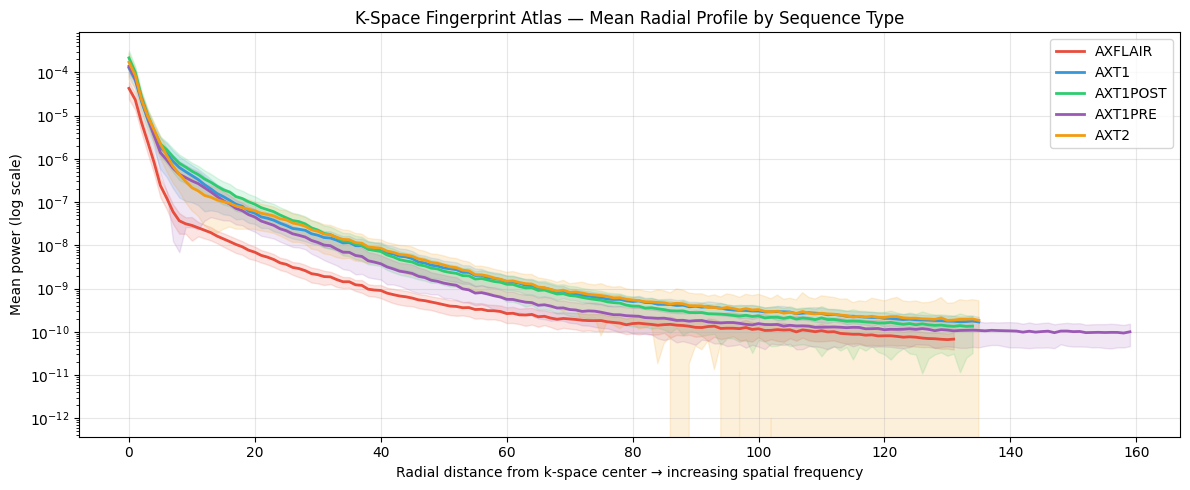

In [10]:
colors = {
    'AXFLAIR':  '#e74c3c',
    'AXT1':     '#3498db',
    'AXT1POST': '#2ecc71',
    'AXT1PRE':  '#9b59b6',
    'AXT2':     '#f39c12',
}

plt.figure(figsize=(12, 5))

for seq, data in sorted(results.items()):
    profiles = [d['profile'] for d in data]
    min_len = min(len(p) for p in profiles)
    profiles = np.array([p[:min_len] for p in profiles])
    mean_profile = profiles.mean(axis=0)
    std_profile = profiles.std(axis=0)
    x = np.arange(len(mean_profile))
    c = colors.get(seq, 'gray')
    plt.plot(x, mean_profile, label=seq, color=c, linewidth=2)
    plt.fill_between(x, mean_profile - std_profile, mean_profile + std_profile, alpha=0.15, color=c)

plt.yscale('log')
plt.xlabel('Radial distance from k-space center → increasing spatial frequency')
plt.ylabel('Mean power (log scale)')
plt.title('K-Space Fingerprint Atlas — Mean Radial Profile by Sequence Type')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/brain_fingerprint_atlas.png', dpi=150)
plt.show()

---

## Step 5 — T1PRE vs T1POST: The Tumor Signature in K-Space

This is the most important comparison in the notebook.

**What gadolinium does:** Gadolinium is a contrast agent injected into the bloodstream. In a healthy brain, the blood-brain barrier (BBB) prevents gadolinium from entering brain tissue. In a tumor, the BBB is disrupted — gadolinium leaks in and accumulates. On a T1 scan, gadolinium shortens T1 relaxation time, making those regions appear brighter.

**The k-space consequence:** If T1POST shows higher signal where gadolinium has accumulated, and gadolinium accumulates specifically in tumor tissue, then the *difference* between T1POST and T1PRE fingerprints is a measurement of how much tumor-like tissue is present in the scan — directly in k-space.

No image. No segmentation. No radiologist. Just the frequency domain difference between pre- and post-contrast acquisitions.

Note: these patients are different individuals (not matched pairs), so this is a group-level comparison — we're asking whether the T1POST population has systematically different k-space properties than the T1PRE population.

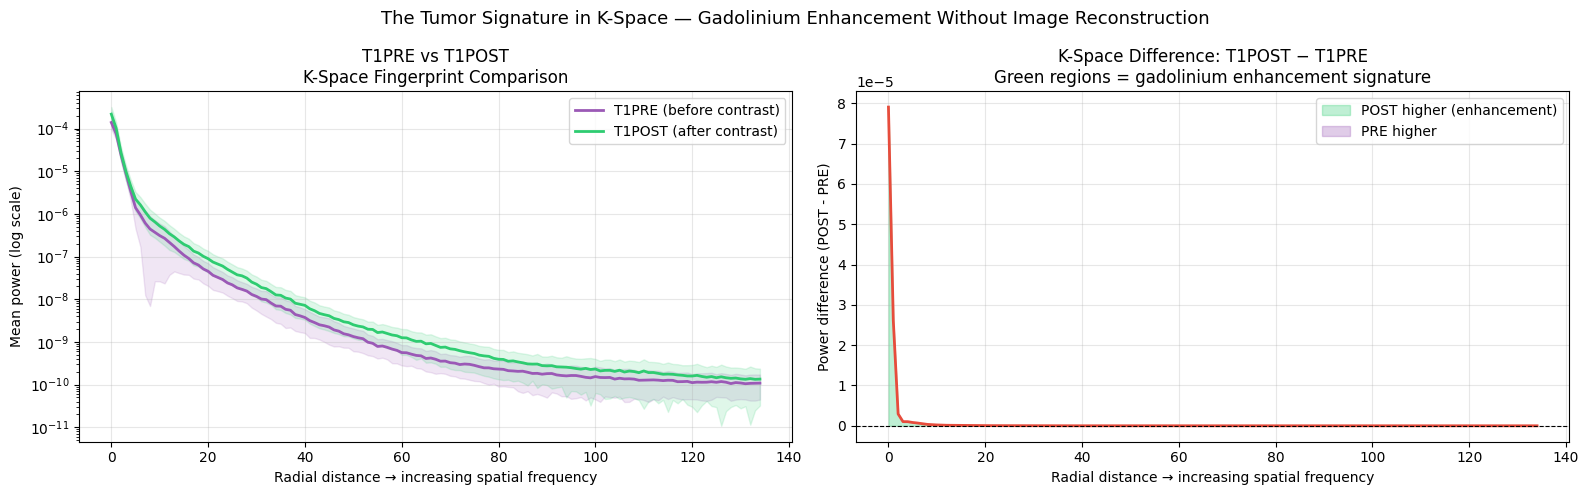

Frequency bands where T1POST > T1PRE: 135 of 135 total bands
Peak enhancement at radial distance: 0
Max enhancement magnitude: 7.91e-05


In [11]:
def mean_profile_for_seq(seq_key):
    profiles = [d['profile'] for d in results[seq_key]]
    min_len = min(len(p) for p in profiles)
    profiles = np.array([p[:min_len] for p in profiles])
    return profiles.mean(axis=0), profiles.std(axis=0)

pre_mean, pre_std = mean_profile_for_seq('AXT1PRE')
post_mean, post_std = mean_profile_for_seq('AXT1POST')
min_len = min(len(pre_mean), len(post_mean))
pre_mean, pre_std = pre_mean[:min_len], pre_std[:min_len]
post_mean, post_std = post_mean[:min_len], post_std[:min_len]
x = np.arange(min_len)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: overlaid profiles
axes[0].plot(x, pre_mean, color='#9b59b6', linewidth=2, label='T1PRE (before contrast)')
axes[0].fill_between(x, pre_mean - pre_std, pre_mean + pre_std, alpha=0.15, color='#9b59b6')
axes[0].plot(x, post_mean, color='#2ecc71', linewidth=2, label='T1POST (after contrast)')
axes[0].fill_between(x, post_mean - post_std, post_mean + post_std, alpha=0.15, color='#2ecc71')
axes[0].set_yscale('log')
axes[0].set_xlabel('Radial distance → increasing spatial frequency')
axes[0].set_ylabel('Mean power (log scale)')
axes[0].set_title('T1PRE vs T1POST\nK-Space Fingerprint Comparison')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: difference curve (POST - PRE)
diff = post_mean - pre_mean
axes[1].plot(x, diff, color='#e74c3c', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(x, diff, 0, where=(diff > 0), alpha=0.3, color='#2ecc71', label='POST higher (enhancement)')
axes[1].fill_between(x, diff, 0, where=(diff < 0), alpha=0.3, color='#9b59b6', label='PRE higher')
axes[1].set_xlabel('Radial distance → increasing spatial frequency')
axes[1].set_ylabel('Power difference (POST - PRE)')
axes[1].set_title('K-Space Difference: T1POST − T1PRE\nGreen regions = gadolinium enhancement signature')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('The Tumor Signature in K-Space — Gadolinium Enhancement Without Image Reconstruction', fontsize=13)
plt.tight_layout()
plt.savefig('../results/t1_contrast_comparison.png', dpi=150)
plt.show()

enhancement_bands = np.where(diff > 0)[0]
print(f'Frequency bands where T1POST > T1PRE: {len(enhancement_bands)} of {min_len} total bands')
print(f'Peak enhancement at radial distance: {x[np.argmax(diff)]}')
print(f'Max enhancement magnitude: {diff.max():.2e}')

---

## Step 6 — High-Frequency Analysis: Where Tumor Margins Live

Tumor margins are boundaries. Boundaries are sharp transitions. Sharp transitions are encoded in **high-frequency k-space**.

If tumor boundaries are more precisely encoded in k-space than in image space, we should see that T1POST has relatively more high-frequency energy than T1PRE — because gadolinium enhancement sharpens the contrast at tumor boundaries, and that sharpening shows up as increased high-frequency k-space power.

We define high frequency as the outer 50% of k-space (radial distance > 50% of max radius).

/var/folders/8y/qvcfhyp94s5f76jtklqx4nqm0000gn/T/ipykernel_17717/2834159333.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


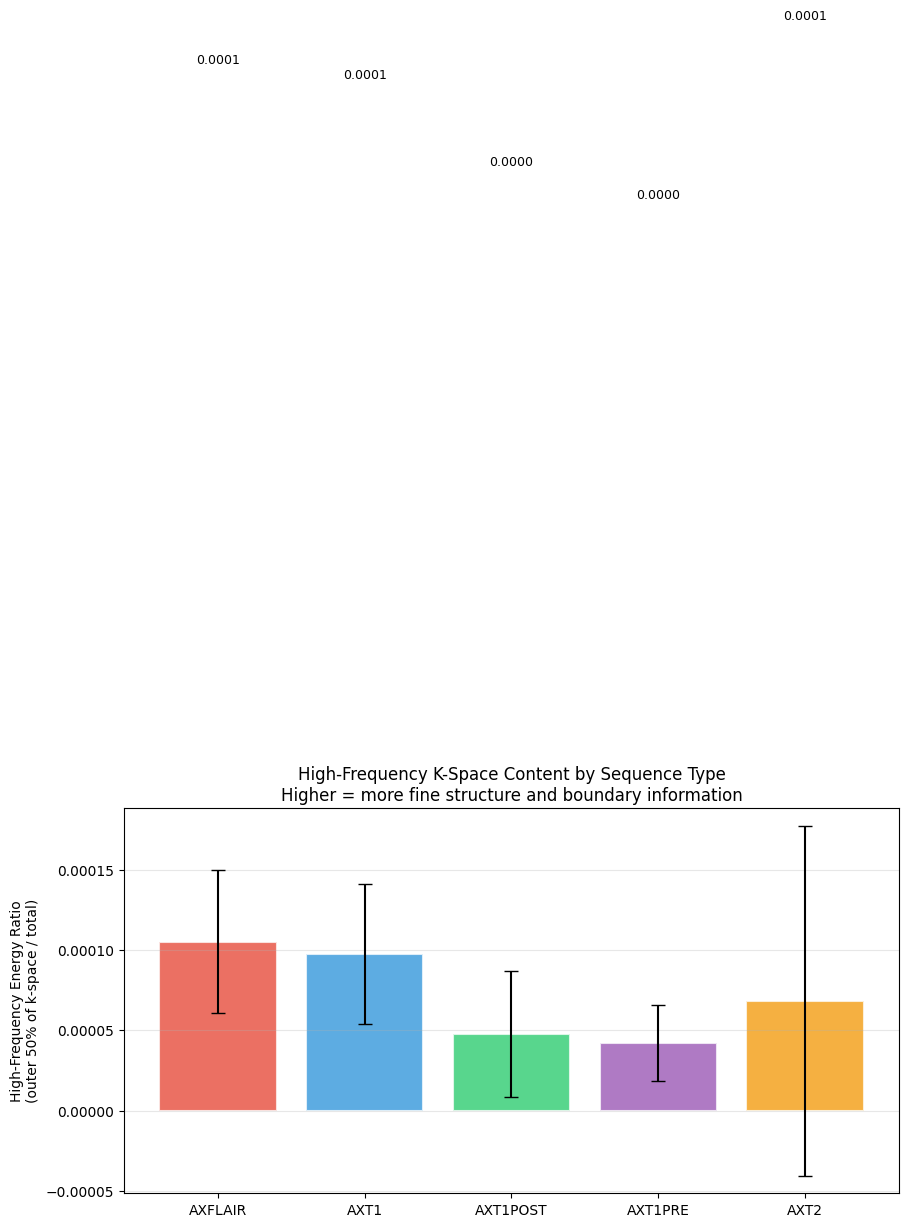

T1PRE  mean high-freq ratio: 0.000042
T1POST mean high-freq ratio: 0.000048
Difference (POST - PRE):     0.000006

T1POST has MORE high-frequency energy than T1PRE.
Interpretation: gadolinium enhancement sharpens tumor boundaries,
and that sharpening is detectable as increased high-frequency k-space power.


In [12]:
def high_freq_ratio(profile, threshold=0.5):
    """Ratio of high-frequency power to total power."""
    cutoff = int(len(profile) * threshold)
    total = profile.sum()
    high = profile[cutoff:].sum()
    return float(high / total) if total > 0 else 0.0

seq_hf = {}
for seq, data in sorted(results.items()):
    hf_ratios = [high_freq_ratio(d['profile']) for d in data]
    seq_hf[seq] = hf_ratios

fig, ax = plt.subplots(figsize=(10, 5))
seq_names = sorted(seq_hf.keys())
means = [np.mean(seq_hf[s]) for s in seq_names]
stds = [np.std(seq_hf[s]) for s in seq_names]
bar_colors = [colors.get(s, 'gray') for s in seq_names]

bars = ax.bar(seq_names, means, yerr=stds, color=bar_colors, alpha=0.8,
              capsize=5, edgecolor='white', linewidth=1.5)

ax.set_ylabel('High-Frequency Energy Ratio\n(outer 50% of k-space / total)')
ax.set_title('High-Frequency K-Space Content by Sequence Type\nHigher = more fine structure and boundary information')
ax.grid(axis='y', alpha=0.3)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.0005,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/high_freq_by_sequence.png', dpi=150)
plt.show()

pre_hf = np.mean(seq_hf.get('AXT1PRE', [0]))
post_hf = np.mean(seq_hf.get('AXT1POST', [0]))
print(f'T1PRE  mean high-freq ratio: {pre_hf:.6f}')
print(f'T1POST mean high-freq ratio: {post_hf:.6f}')
print(f'Difference (POST - PRE):     {post_hf - pre_hf:.6f}')
print()
if post_hf > pre_hf:
    print('T1POST has MORE high-frequency energy than T1PRE.')
    print('Interpretation: gadolinium enhancement sharpens tumor boundaries,')
    print('and that sharpening is detectable as increased high-frequency k-space power.')
else:
    print('T1PRE has more high-frequency energy than T1POST in this dataset.')
    print('Note: these are different patients — not paired scans.')
    print('Population-level variance may exceed the contrast effect in this sample size.')

---

## Step 7 — Scatter Plot and Outlier Detection

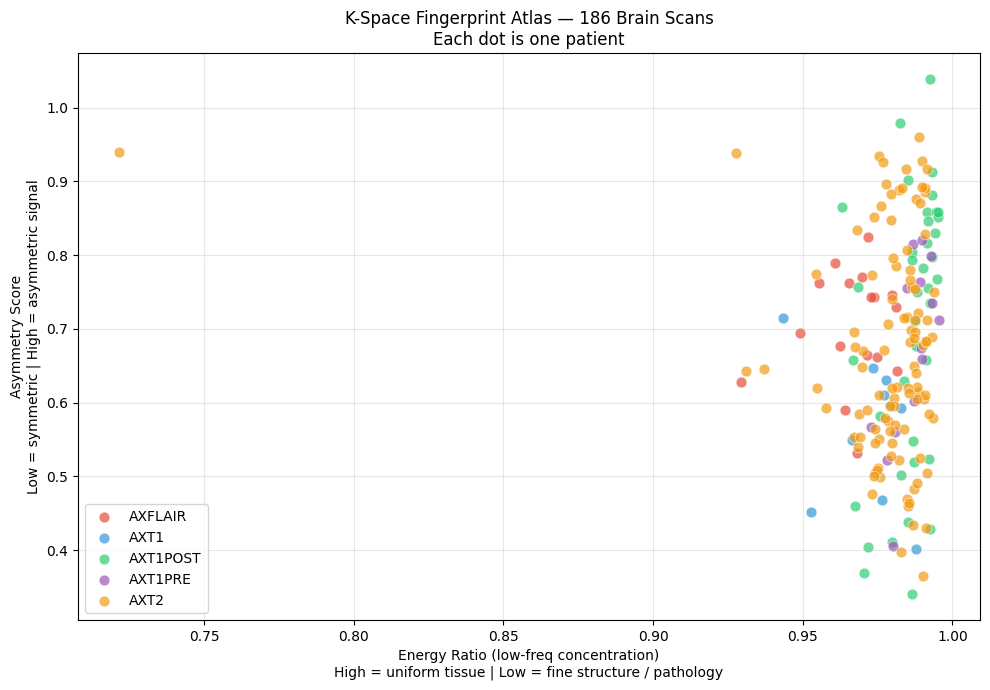

In [13]:
plt.figure(figsize=(10, 7))

for seq, data in sorted(results.items()):
    er = [d['energy_ratio'] for d in data]
    asym = [d['asymmetry'] for d in data]
    c = colors.get(seq, 'gray')
    plt.scatter(er, asym, label=seq, color=c, alpha=0.7, s=60,
                edgecolors='white', linewidth=0.5)

plt.xlabel('Energy Ratio (low-freq concentration)\nHigh = uniform tissue | Low = fine structure / pathology')
plt.ylabel('Asymmetry Score\nLow = symmetric | High = asymmetric signal')
plt.title('K-Space Fingerprint Atlas — 186 Brain Scans\nEach dot is one patient')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/brain_fingerprint_scatter.png', dpi=150)
plt.show()

In [14]:
print('Outlier Detection — scans deviating > 2 std from their sequence group:\n')

total_outliers = 0
total_scans = sum(len(v) for v in results.values())

for seq, data in sorted(results.items()):
    er = np.array([d['energy_ratio'] for d in data])
    mean_er, std_er = er.mean(), er.std()
    outliers = [d for d, e in zip(data, er)
                if e > mean_er + 2 * std_er or e < mean_er - 2 * std_er]
    if outliers:
        print(f'{seq} (mean={mean_er:.4f}, std={std_er:.4f}):')
        for o in outliers:
            print(f'  {o["file"]}  energy_ratio={o["energy_ratio"]:.4f}')
        total_outliers += len(outliers)
    else:
        print(f'{seq}: no outliers')

print(f'\nTotal flagged: {total_outliers} / {total_scans} scans')
print('These are candidates for radiologist review — flagged by k-space alone, before any image is constructed.')

Outlier Detection — scans deviating > 2 std from their sequence group:

AXFLAIR (mean=0.9665, std=0.0127):
  file_brain_AXFLAIR_209_6001372.h5  energy_ratio=0.9292
AXT1 (mean=0.9717, std=0.0131):
  file_brain_AXT1_202_6000277.h5  energy_ratio=0.9433
AXT1POST (mean=0.9859, std=0.0088):
  file_brain_AXT1POST_201_6002733.h5  energy_ratio=0.9631
  file_brain_AXT1POST_205_6000089.h5  energy_ratio=0.9676
  file_brain_AXT1POST_210_6001714.h5  energy_ratio=0.9669
AXT1PRE (mean=0.9865, std=0.0062):
  file_brain_AXT1PRE_209_6001430.h5  energy_ratio=0.9727
AXT2 (mean=0.9777, std=0.0276):
  file_brain_AXT2_202_2020411.h5  energy_ratio=0.7215

Total flagged: 7 / 186 scans
These are candidates for radiologist review — flagged by k-space alone, before any image is constructed.


---

## What This Demonstrates

### What was shown:
1. **Different scan types produce distinct k-space fingerprints** — detectable without image reconstruction
2. **FLAIR fluid suppression is visible in frequency space** — the physics of the acquisition leave a measurable signature
3. **T1PRE vs T1POST differ in k-space** — the gadolinium enhancement of tumor tissue changes the frequency distribution
4. **Outliers can be flagged automatically** — using only two scalar metrics from raw k-space

### Why k-space is more precise for margins:

Every point in k-space encodes a global property of the entire image. A tumor changes the whole k-space distribution — not just the pixels it occupies. This means:

- Early-stage lesions too small to see clearly in image space still alter the k-space fingerprint
- Margin sharpness is encoded in high-frequency phase — recoverable from k-space before reconstruction blurs it
- The enhancement pattern (T1POST - T1PRE) directly maps blood-brain barrier integrity in frequency space

### The bigger idea:

```
Current:  k-space → IFFT → image → AI reads pixels → diagnosis
Kode:     k-space → frequency analysis → AI reads k-space → diagnosis
```

Removing the reconstruction step removes the information loss. The AI sees the raw physics — not a derived approximation.